In [34]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
np.random.seed(42)
num_rows = 3500

In [36]:
cities = ["Nairobi", "Mombasa", "Kisumu", "Nakuru", "Eldoret"]
regions = ["Nairobi", "Coast", "Nyanza", "Rift Valley"]
categories = ["Electronics", "Clothing", "Groceries", "Furniture", "Beauty"]
sub_categories = {
    "Electronics": ["Phone", "Laptop", "TV"],
    "Clothing": ["Shirt", "Shoes", "Jeans"],
    "Groceries": ["Food", "Beverages", "Snacks"],
    "Furniture": ["Chair", "Table", "Bed"],
    "Beauty": ["Makeup", "Skincare", "Haircare"]
}
channels = ["Online", "In-Store"]
payment_methods = ["M-Pesa", "Cash", "Card"]
genders = ["Male", "Female"]

In [73]:
# HELPER FUNCTIONS

def random_date(start, end):
    return start + timedelta(days=random.randint(0, (end - start).days))

In [74]:
data = []

start_date = datetime(2022, 1, 1)
end_date = datetime(2024, 12, 31)

for i in range(num_rows):
    customer_id = f"CUST{random.randint(1000, 1999)}"
    transaction_id = f"TXN{i+1:05d}"
    
    category = random.choice(categories)
    sub_category = random.choice(sub_categories[category])
    
    quantity = np.random.randint(1, 5)
    unit_price = round(np.random.uniform(200, 50000), 2)
    discount = round(np.random.choice([0, 0, 0, 50, 100, 200, 500]), 2)
    
    total_sales = (quantity * unit_price) - discount
    cost = total_sales * np.random.uniform(0.6, 0.9)
    profit = total_sales - cost
    
    row = {
        "Transaction_ID": transaction_id,
        "Customer_ID": customer_id,
        "Transaction_Date": random_date(start_date, end_date),
        "City": random.choice(cities),
        "Region": random.choice(regions),
        "Gender": random.choice(genders),
        "Category": category,
        "Sub_Category": sub_category,
        "Quantity": quantity,
        "Unit_Price": unit_price,
        "Discount": discount,
        "Total_Sales": round(total_sales, 2),
        "Cost": round(cost, 2),
        "Profit": round(profit, 2),
        "Channel": random.choice(channels),
        "Payment_Method": random.choice(payment_methods)
    }
    
    data.append(row)

# CREATE DATAFRAME

df = pd.DataFrame(data)

# Sort by date (makes it more realistic)
df = df.sort_values(by="Transaction_Date")

# SAVE FILES

df.to_csv("retail_dataset_kenya.csv", index=False)
df.to_excel("retail_dataset_kenya.xlsx", index=False)

print("Dataset generated successfully!")
print(df.head())

Dataset generated successfully!
     Transaction_ID Customer_ID Transaction_Date     City       Region  \
2361       TXN02362    CUST1857       2022-01-01  Nairobi        Coast   
2571       TXN02572    CUST1391       2022-01-01  Nairobi       Nyanza   
469        TXN00470    CUST1480       2022-01-01   Kisumu      Nairobi   
525        TXN00526    CUST1553       2022-01-01   Nakuru  Rift Valley   
1563       TXN01564    CUST1138       2022-01-02  Nairobi      Nairobi   

      Gender     Category Sub_Category  Quantity  Unit_Price  Discount  \
2361  Female  Electronics        Phone         3    19819.27         0   
2571    Male    Furniture        Table         2    31445.27         0   
469     Male    Groceries    Beverages         3    40517.45       500   
525     Male    Groceries    Beverages         3    12783.45         0   
1563    Male    Furniture        Table         3    26833.94       200   

      Total_Sales      Cost    Profit   Channel Payment_Method  
2361     5945

In [75]:
df.head()

,Transaction_ID,Customer_ID,Transaction_Date,City,Region,Gender,Category,Sub_Category,Quantity,Unit_Price,Discount,Total_Sales,Cost,Profit,Channel,Payment_Method
2361,TXN02362,CUST1857,2022-01-01,Nairobi,Coast,Female,Electronics,Phone,3,19819.27,0,59457.81,51209.60,8248.21,Online,Card
2571,TXN02572,CUST1391,2022-01-01,Nairobi,Nyanza,Male,Furniture,Table,2,31445.27,0,62890.54,47503.52,15387.02,Online,M-Pesa
469,TXN00470,CUST1480,2022-01-01,Kisumu,Nairobi,Male,Groceries,Beverages,3,40517.45,500,121052.35,82724.34,38328.01,Online,Card
525,TXN00526,CUST1553,2022-01-01,Nakuru,Rift Valley,Male,Groceries,Beverages,3,12783.45,0,38350.35,33997.91,4352.44,Online,Cash
1563,TXN01564,CUST1138,2022-01-02,Nairobi,Nairobi,Male,Furniture,Table,3,26833.94,200,80301.82,55102.30,25199.52,In-Store,Cash


In [108]:
#Data Understanding

In [76]:
df.shape

(3500, 16)

In [77]:
df.columns

Index(['Transaction_ID', 'Customer_ID', 'Transaction_Date', 'City', 'Region',
       'Gender', 'Category', 'Sub_Category', 'Quantity', 'Unit_Price',
       'Discount', 'Total_Sales', 'Cost', 'Profit', 'Channel',
       'Payment_Method'],
      dtype='object')

In [42]:
df.dtypes

Transaction_ID              object
Customer_ID                 object
Transaction_Date    datetime64[ns]
City                        object
Region                      object
Gender                      object
Category                    object
Sub_Category                object
Quantity                     int64
Unit_Price                 float64
Discount                     int64
Total_Sales                float64
Cost                       float64
Profit                     float64
Channel                     object
Payment_Method              object
dtype: object

In [78]:
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])

In [79]:
df['Year'] = df['Transaction_Date'].dt.year
df['Month'] = df['Transaction_Date'].dt.month
df['Day'] = df['Transaction_Date'].dt.day
df['Day_Name'] = df['Transaction_Date'].dt.day_name()

In [80]:
df.describe(include = "all")

,Transaction_ID,Customer_ID,Transaction_Date,City,Region,Gender,Category,Sub_Category,Quantity,Unit_Price,Discount,Total_Sales,Cost,Profit,Channel,Payment_Method,Year,Month,Day,Day_Name
count,3500,3500,3500,3500,3500,3500,3500,3500,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500,3500,3500.000000,3500.000000,3500.000000,3500
unique,3500,964,NaN,5,4,2,5,15,NaN,NaN,NaN,NaN,NaN,NaN,2,3,NaN,NaN,NaN,7
top,TXN02362,CUST1727,NaN,Mombasa,Coast,Male,Furniture,Phone,NaN,NaN,NaN,NaN,NaN,NaN,Online,Card,NaN,NaN,NaN,Friday
freq,1,10,NaN,718,931,1767,749,258,NaN,NaN,NaN,NaN,NaN,NaN,1750,1203,NaN,NaN,NaN,526
mean,NaN,NaN,2023-07-01 16:41:00.342856960,NaN,NaN,NaN,NaN,NaN,2.506857,25247.825669,123.985714,62826.054551,47232.136526,15593.918026,NaN,NaN,2023.003429,6.464857,15.737714,NaN
min,NaN,NaN,2022-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,1.000000,211.990000,0.000000,185.060000,123.830000,35.380000,NaN,NaN,2022.000000,1.000000,1.000000,NaN
25%,NaN,NaN,2022-09-30 00:00:00,NaN,NaN,NaN,NaN,NaN,2.000000,12665.602500,0.000000,23985.365000,17822.495000,5195.295000,NaN,NaN,2022.000000,3.000000,8.000000,NaN
50%,NaN,NaN,2023-07-05 00:00:00,NaN,NaN,NaN,NaN,NaN,2.000000,25201.050000,50.000000,48420.300000,36689.920000,11260.130000,NaN,NaN,2023.000000,6.000000,16.000000,NaN
75%,NaN,NaN,2024-04-02 06:00:00,NaN,NaN,NaN,NaN,NaN,4.000000,37967.477500,200.000000,91974.565000,69480.215000,21910.762500,NaN,NaN,2024.000000,9.000000,23.000000,NaN
max,NaN,NaN,2024-12-31 00:00:00,NaN,NaN,NaN,NaN,NaN,4.000000,49983.730000,500.000000,199060.440000,173835.870000,76010.170000,NaN,NaN,2024.000000,12.000000,31.000000,NaN


In [109]:
#Data Cleaning

In [81]:
df_new = df.drop(columns = 'Transaction_ID')

In [82]:
df_new.isna().sum().sum()

np.int64(0)

In [83]:
df.duplicated().sum()

np.int64(0)

In [84]:
df.columns

Index(['Transaction_ID', 'Customer_ID', 'Transaction_Date', 'City', 'Region',
       'Gender', 'Category', 'Sub_Category', 'Quantity', 'Unit_Price',
       'Discount', 'Total_Sales', 'Cost', 'Profit', 'Channel',
       'Payment_Method', 'Year', 'Month', 'Day', 'Day_Name'],
      dtype='object')

In [85]:
payment_method_counts = df['Payment_Method'].value_counts()
payment_method_counts

Payment_Method
Card      1203
Cash      1172
M-Pesa    1125
Name: count, dtype: int64

In [86]:
city_counts = df['City'].value_counts()
city_counts

City
Mombasa    718
Kisumu     715
Nairobi    702
Nakuru     696
Eldoret    669
Name: count, dtype: int64

In [87]:
channel_counts = df['Channel'].value_counts()
channel_counts

Channel
Online      1750
In-Store    1750
Name: count, dtype: int64

In [88]:
region_counts = df['Region'].value_counts()
region_counts

Region
Coast          931
Nyanza         889
Nairobi        856
Rift Valley    824
Name: count, dtype: int64

In [89]:
gender_counts = df['Gender'].value_counts()
gender_counts

Gender
Male      1767
Female    1733
Name: count, dtype: int64

In [90]:
product_category_counts = df['Category'].value_counts()
product_category_counts

Category
Furniture      749
Groceries      711
Electronics    705
Beauty         676
Clothing       659
Name: count, dtype: int64

In [110]:
#Exploratory Analysis

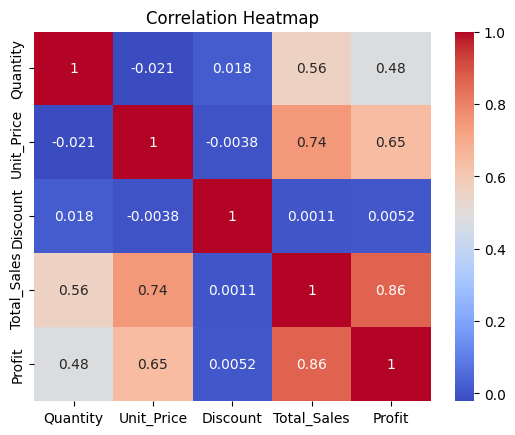

In [119]:
corr = df[['Quantity','Unit_Price','Discount','Total_Sales','Profit']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.savefig('Correlation Heatmap.png')
plt.show()

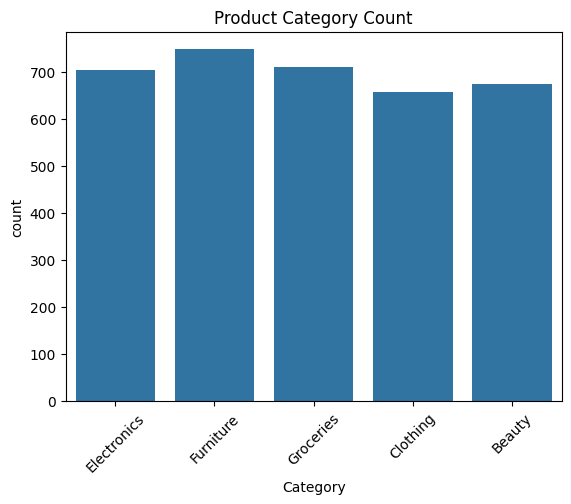

In [95]:
# Count by category
sns.countplot(data=df, x='Category')
plt.xticks(rotation=45)
plt.title("Product Category Count")
plt.show()

In [98]:
#Electronics generate the highest revenue but lower profit margins

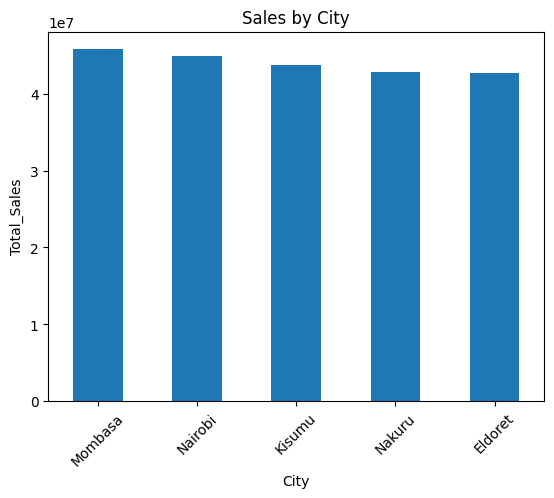

In [124]:
city_sales = df.groupby('City')['Total_Sales'].sum().sort_values(ascending=False)

city_sales.plot(kind='bar')
plt.title("Sales by City")
plt.ylabel("Total_Sales")
plt.xticks(rotation=45)
plt.savefig("Sales by City.png")
plt.show()

In [99]:
#Most sales happen in Nairobi and Mombasa

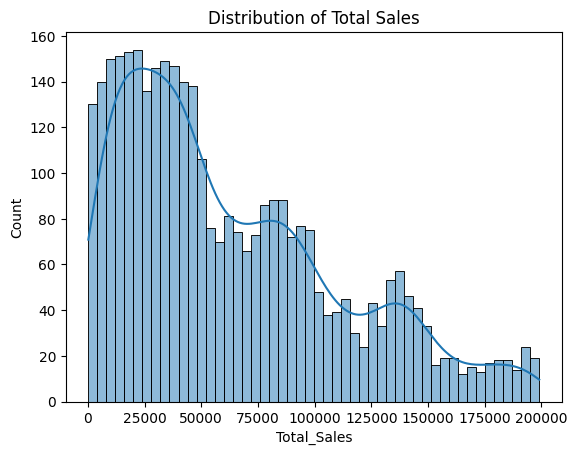

In [120]:
sns.histplot(df['Total_Sales'], bins=50, kde=True)
plt.title("Distribution of Total Sales")
plt.savefig("Distribution of Total Sales.png")
plt.show()

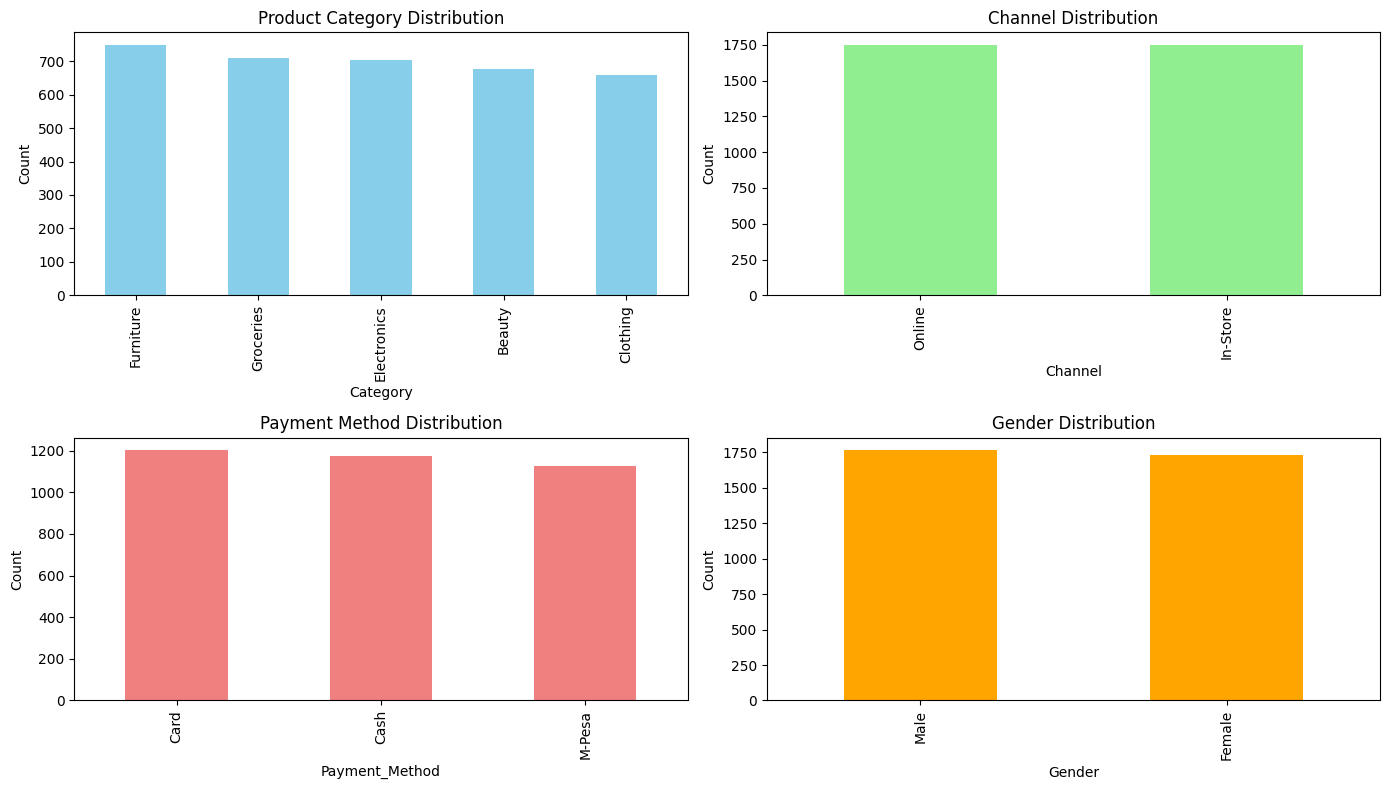

In [122]:
plt.figure(figsize=(14,8))

plt.subplot(2, 2, 1)
product_category_counts.plot(kind='bar', color='skyblue')
plt.title('Product Category Distribution')
plt.ylabel('Count')

plt.subplot(2, 2, 2)
channel_counts.plot(kind='bar', color='lightgreen')
plt.title('Channel Distribution')
plt.ylabel('Count')

plt.subplot(2, 2, 3)
payment_method_counts.plot(kind='bar', color='lightcoral')
plt.title('Payment Method Distribution')
plt.ylabel('Count')

plt.subplot(2, 2, 4)
city_counts.plot(kind='bar', color='orange')
plt.title('City Distribution')
plt.ylabel('Count')

plt.subplot(2, 2, 4)
gender_counts.plot(kind='bar', color='orange')
plt.title('Gender Distribution')
plt.ylabel('Count')

plt.tight_layout()

In [101]:
#Card is the most used payment method

In [92]:
df['purchase-Year-Month'] = df['Transaction_Date'].dt.to_period('M')

In [64]:
purchase_trend= df.groupby('purchase-Year-Month').size()

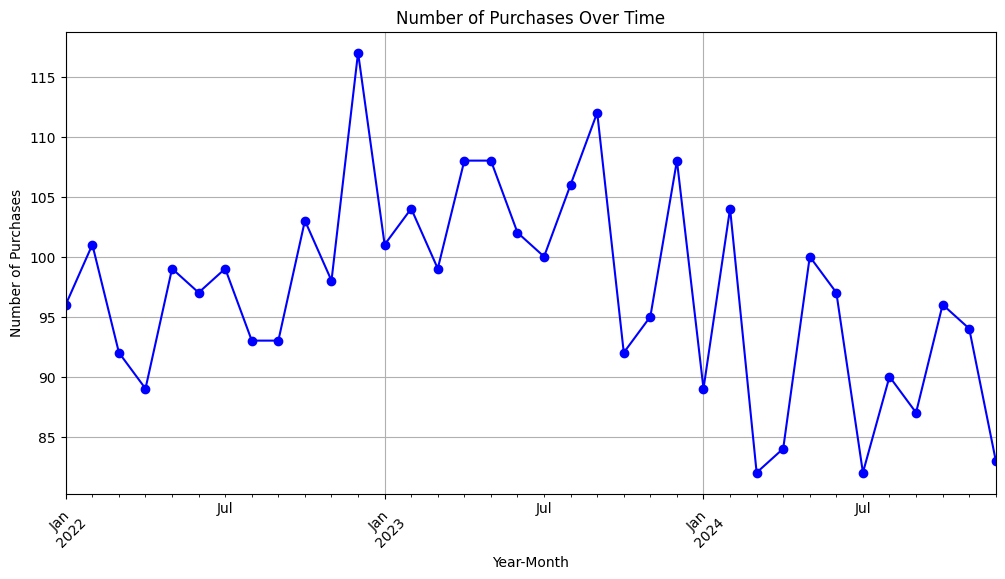

In [123]:
plt.figure(figsize=(12,6))
purchase_trend.plot(kind='line', marker='o' ,color='blue')
plt.title('Number of Purchases Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Number of Purchases')
plt.grid(True)
plt.xticks(rotation=45)           
plt.savefig("Number of Purchases Over Time.png")
plt.show()

In [114]:
#Key Insights

#Electronics generate the highest revenue but lower profit margins
#Most sales happen in Nairobi and Mombasa
#Card is the most used payment method